# GBD_6 — Full-Basis Propagation

## What changed from GBD_5
GBD_5 propagated **one** beamlet analytically. GBD_6 propagates **all 135** and sums them with the GBD_4 coefficients to produce `E(x, L)` for the original top-hat field at any chosen propagation distance L.

## The one idea this notebook is built on
Once `c` is solved at z = 0 (the GBD_4 fit), the **same `c`** works at every other z. Only the basis functions evolve:

$$E(x, L) = \sum_{n=1}^{N} c_n \, G_n(x, L)$$

No new optimization, no new fit. This is why GBD is cheap compared to FFT-based propagation when you have many similar source fields (e.g., a LiDAR scanner sweeping the beam direction — every shot reuses the basis).

## What's new in this notebook
1. The full GBD_4 setup is rebuilt at the top (we need coefficients and beam info).
2. The GBD_5 propagator is pasted in (notebooks stay self-contained).
3. A new `propagate_basis(...)` function loops over beamlets, propagates each, sums weighted by `c`.
4. A z = 0 sanity check: propagated sum must equal GBD_4's reconstruction (machine epsilon).
5. Multi-z snapshots — amplitude AND phase.
6. Continuous heatmap of `|E(x, z)|` and phase showing diffraction unfolding.

## What's intentionally NOT here yet
- Independent ground-truth comparison (angular spectrum FFT) — that's GBD_7.
- Quantitative error vs. z — GBD_8.

## FMCW-relevant note
Each beamlet has a slightly different `kz_n = sqrt(k² − kx_n²)`. So beamlets with different tilts dephase against each other as z grows. This per-beamlet differential phase is *exactly* what produces diffraction — and it's what the FMCW receiver eventually uses (against the local oscillator) to extract range and Doppler.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Same x-grid, wavelength, and beam width as GBD_4 / GBD_5
# --------------------------------------------------
x_min, x_max, Nx = -5.0, 5.0, 1000
x = np.linspace(x_min, x_max, Nx)

wavelength = 0.6328       # micrometers (HeNe)
k = 2 * np.pi / wavelength
w0 = 0.5                  # beamlet waist
zR = np.pi * w0**2 / wavelength
print(f"Rayleigh range zR = {zR:.4f} micrometers")

Rayleigh range zR = 1.2411 micrometers


## Rebuild the GBD_4 basis and coefficients

We need the same 135-beamlet basis as GBD_4, the per-beamlet `(x0, kx)` info, and the regularized-least-squares coefficients. This block is essentially copied from GBD_4 — kept identical so the propagated result at z = 0 matches GBD_4's reconstruction exactly.

In [2]:
# --- Top-hat source ---
a = 1.0
E_original = np.zeros_like(x)
E_original[np.abs(x) < a] = 1.0

# --- Basis layout ---
N_positions, N_angles = 15, 9
centers = np.linspace(-3.0, 3.0, N_positions)
theta_max = 0.10
angles = np.linspace(-theta_max, theta_max, N_angles)
kx_values = k * np.sin(angles)
N_gaussians = N_positions * N_angles

# --- Build basis matrix and beam info ---
G = np.zeros((Nx, N_gaussians), dtype=complex)
beam_info = []  # (index, x0, theta, kx) for each column of G
idx = 0
for x0 in centers:
    for j, kx in enumerate(kx_values):
        envelope = np.exp(-((x - x0)**2) / w0**2)
        phase = np.exp(1j * kx * x)
        G[:, idx] = envelope * phase
        beam_info.append((idx, x0, angles[j], kx))
        idx += 1

# --- Tikhonov-regularized least squares (same lambda as GBD_4) ---
lambda_reg = 0.01
A = G.conj().T @ G + lambda_reg * np.eye(G.shape[1])
b = G.conj().T @ E_original
coefficients = np.linalg.solve(A, b)

E_reconstructed_z0 = G @ coefficients

print(f"Basis: {N_gaussians} beamlets")
print(f"Max |coefficient| = {np.max(np.abs(coefficients)):.4f}")
print(f"Reconstruction error at z=0 (||E_orig - E_recon||_2) = {np.linalg.norm(E_original - E_reconstructed_z0):.4f}")

Basis: 135 beamlets
Max |coefficient| = 1.1714
Reconstruction error at z=0 (||E_orig - E_recon||_2) = 2.5021


## Paste in the GBD_5 propagator

Identical to GBD_5 — propagates one tilted Gaussian beamlet to a chosen z using the q-parameter form. Notebooks stay self-contained so we don't introduce cross-notebook import dependencies.

In [3]:
def propagate_tilted_gaussian(x, x0, w0, kx, k, z):
    """Single 1-D tilted Gaussian beamlet propagated to distance z.

    Returns (complex E(x, z), diagnostics dict). See GBD_5 for derivation.
    """
    wavelength = 2 * np.pi / k
    zR = np.pi * w0**2 / wavelength
    x_c = x0 + (kx / k) * z          # walking center (paraxial)

    q0 = -1j * zR                     # sign convention: outgoing exp(+i*k*z)
    qz = z + q0
    envelope = np.sqrt(q0 / qz) * np.exp(1j * k * (x - x_c)**2 / (2 * qz))

    kz = np.sqrt(k**2 - kx**2)
    longitudinal = np.exp(1j * kz * z)
    tilt = np.exp(1j * kx * x)

    E = envelope * longitudinal * tilt

    diag = {
        "z": z, "zR": zR,
        "w(z)": w0 * np.sqrt(1 + (z / zR)**2),
        "R(z)": np.inf if z == 0 else z * (1 + (zR / z)**2),
        "Gouy(z)": np.arctan(z / zR),
        "x_center": x_c,
    }
    return E, diag

## The new piece: `propagate_basis`

This loops over every beamlet in the basis, applies `propagate_tilted_gaussian` with that beamlet's `(x0, kx)`, builds a propagated basis matrix `G_propagated[:, n] = G_n(x, z)`, and returns the weighted sum `G_propagated @ coefficients`.

**Why a loop instead of vectorizing.** A loop is the clearest way to show the per-beamlet propagation. The cost is `N_beams × N_x` complex operations per z, fast enough for thousands of z values. We can vectorize later if needed.

**The sanity check.** Calling `propagate_basis(..., z=0)` should give back GBD_4's `E_reconstructed` exactly — every beamlet propagator collapses to its z = 0 form, the propagated G equals the original G, and the sum is identical. We verify this numerically.

In [4]:
def propagate_basis(x, beam_info, w0, k, z, coefficients):
    """Propagate every beamlet to z; sum weighted by coefficients.

    Returns the complex propagated field E(x, z).
    """
    Nx_local = len(x)
    N = len(beam_info)
    G_propagated = np.zeros((Nx_local, N), dtype=complex)
    for n in range(N):
        _, x0_n, _, kx_n = beam_info[n]
        E_n, _ = propagate_tilted_gaussian(x, x0_n, w0, kx_n, k, z=z)
        G_propagated[:, n] = E_n
    return G_propagated @ coefficients

# ----- Sanity check: at z=0 the propagated sum must equal GBD_4's reconstruction -----
E_at_0 = propagate_basis(x, beam_info, w0, k, z=0.0, coefficients=coefficients)
err_z0 = np.max(np.abs(E_at_0 - E_reconstructed_z0))
print(f"Max |propagate_basis(z=0) - E_reconstructed_z0| = {err_z0:.2e}  (should be ~0)")

Max |propagate_basis(z=0) - E_reconstructed_z0| = 5.03e-16  (should be ~0)


## Multi-z snapshots — amplitude AND phase

We propagate the full top-hat to z = 0, zR/2, zR, 2·zR, 5·zR. Things to look for:
- **z = 0 amplitude** should hug the original top-hat (with GBD_4's known reconstruction error — Fresnel-style ripples on the plateau).
- As z grows, the plateau crumbles, edges develop ringing, the field broadens — classic Fresnel diffraction of an aperture.
- The **phase** picks up structure rapidly: at z > 0 we see the curling wavefront. The phase wraps in ±π every time the optical path changes by half a wavelength.

FMCW LiDAR consumes the right column (phase) more than the left (amplitude) — that's where range information lives.

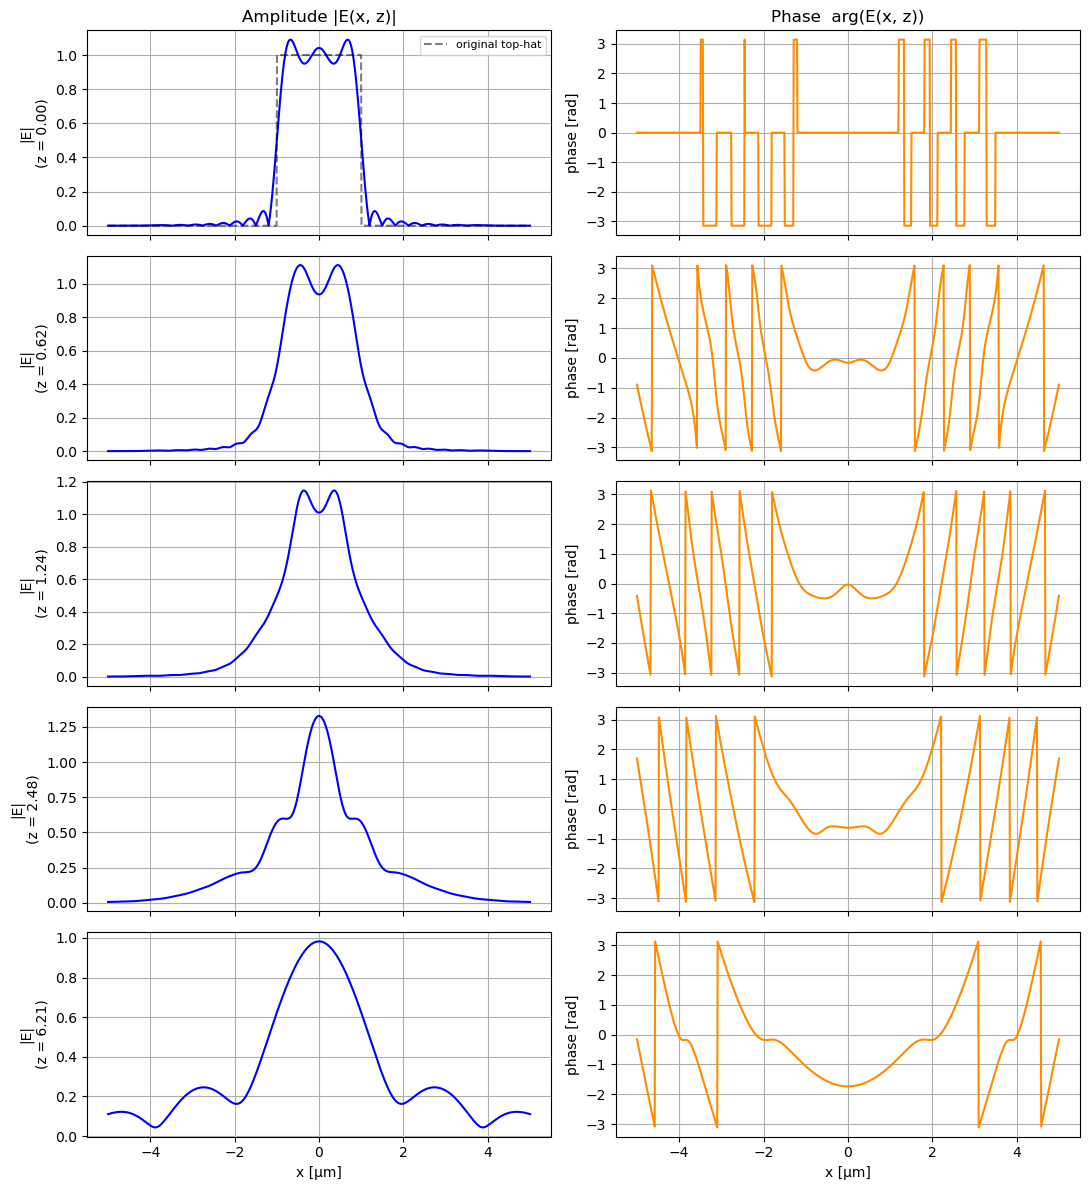

In [5]:
z_snaps = [0.0, 0.5*zR, zR, 2*zR, 5*zR]

fig, axes = plt.subplots(len(z_snaps), 2, figsize=(11, 2.4*len(z_snaps)),
                         sharex=True)

for row, z in enumerate(z_snaps):
    E_z = propagate_basis(x, beam_info, w0, k, z=z, coefficients=coefficients)

    axes[row, 0].plot(x, np.abs(E_z), color='blue')
    if row == 0:
        axes[row, 0].plot(x, E_original, 'k--', alpha=0.5, label='original top-hat')
        axes[row, 0].legend(loc='upper right', fontsize=8)
    axes[row, 0].set_ylabel(f"|E|\n(z = {z:.2f})")
    axes[row, 0].grid(True)

    axes[row, 1].plot(x, np.angle(E_z), color='darkorange')
    axes[row, 1].set_ylabel("phase [rad]")
    axes[row, 1].grid(True)

axes[0, 0].set_title("Amplitude |E(x, z)|")
axes[0, 1].set_title("Phase  arg(E(x, z))")
axes[-1, 0].set_xlabel("x [µm]")
axes[-1, 1].set_xlabel("x [µm]")
plt.tight_layout()
plt.show()

## Continuous heatmap — diffraction unfolding with z

Snapshots show the field at a few discrete z values; a 2-D heatmap shows the whole story. We sample many z values from 0 to 5·zR and plot `|E(x, z)|` and `arg E(x, z)` as colored 2-D images.

What you should see in `|E|`:
- A bright top-hat band at the bottom (z ≈ 0).
- The bright region narrows in some places and ripples on the edges as z grows — the Fresnel diffraction pattern.
- For very large z the field would converge to the far-field sinc-like pattern (we don't quite get there in 5·zR).

What you should see in the phase plot:
- Near z = 0, mostly flat phase inside the aperture.
- A characteristic curling pattern emerging — the wavefront is curving away from the source.
- For FMCW: the rate at which this phase pattern winds vs. z is, in the round-trip case, what drives the beat frequency.

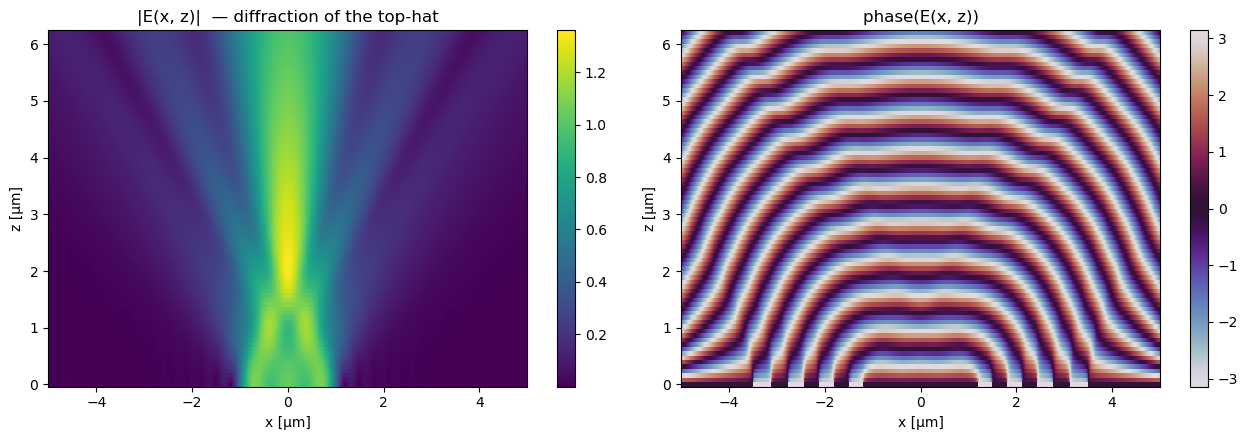

In [6]:
N_z = 80
z_array = np.linspace(0.0, 5*zR, N_z)
E_field_2d = np.zeros((N_z, Nx), dtype=complex)

for i, z in enumerate(z_array):
    E_field_2d[i, :] = propagate_basis(x, beam_info, w0, k, z=z, coefficients=coefficients)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

im1 = axes[0].pcolormesh(x, z_array, np.abs(E_field_2d), shading='auto', cmap='viridis')
axes[0].set_xlabel("x [µm]")
axes[0].set_ylabel("z [µm]")
axes[0].set_title("|E(x, z)|  — diffraction of the top-hat")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].pcolormesh(x, z_array, np.angle(E_field_2d), shading='auto',
                         cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[1].set_xlabel("x [µm]")
axes[1].set_ylabel("z [µm]")
axes[1].set_title("phase(E(x, z))")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## What we proved here
1. The propagator from GBD_5 plays nicely with the full 135-beamlet sum.
2. At z = 0 the propagated sum equals GBD_4's reconstruction exactly (machine epsilon) — confirms we threaded `(x0, kx)` through correctly.
3. The propagated field looks physically reasonable: the top-hat diffracts as it should, with edge ringing and broadening growing with z.
4. The complex field (phase) is preserved everywhere — the FMCW pipeline downstream can use it.

## What we have NOT proved
That the propagated field is *correct*. "Looks reasonable" ≠ "matches the right answer". The basis is finite (135 beamlets) and the regularization (λ = 0.01) damps high-frequency content; both can introduce systematic error that grows with z. Until we compare against an independent reference, we can't quantify that error.

## Next notebook: GBD_7
Implement angular-spectrum FFT propagation of the same top-hat field, overlay it against the GBD result at one chosen z, and look at residuals (amplitude and phase separately).